# <u>From phase space to Krylov space, one shell at a time</u>

# <i>Project notebook</i>

We begin this notebook by importing the necessary packages and modules.

In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.ndimage import gaussian_filter1d

from KrylovQuantumClassical import util
from KrylovQuantumClassical.Hamiltonian import Hamiltonian
from KrylovQuantumClassical.LanczosClassical import K_complexity
from KrylovQuantumClassical.LMG import LMG
from KrylovQuantumClassical.FP import FP
from KrylovQuantumClassical.LanczosQuantum import LanczosQuantum
from KrylovQuantumClassical.classicalFP import classicalFP, classicalFP_MC
from KrylovQuantumClassical.classicalLMG import classicalLMG, classicalLMG_MC

The structure of the notebook is as follows:

<span style="color:orange">1.</span> The LMG and FP models

<span style="color:orange">2.</span>  Classical Krylov complexity

<span style="color:orange">3.</span>  Quantum Krylov complexity

<u>Disclaimer</u>: this notebook does not aim to exactly reproduce the results shown in the corresponding paper, but instead aims to show how the code works and how those results can be recovered.

The following functions will be useful throughout the notebook.

In [5]:
def one_plot(title: str, x_label: str, y_label: str) -> tuple[plt.Figure, plt.Axes]:
    """
    This function creates a matplotlib figure and axis with specified title and labels. It allows us to easily create consistent plots throughout the code without having to repeat the same code for setting up the figure and axis each time.

    Parameters
    ----------
    title: str
        The title of the plot.

    x_label: str
        The label for the x-axis.

    y_label: str
        The label for the y-axis.

    Returns
    -------
    fig: matplotlib.figure.Figure
        The created figure object.

    ax: matplotlib.axes._axes.Axes
        The created axis object.

    Example
    -------
    (see throughout the notebook for examples of how to use this function)
    """
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.set_title(title, fontsize = 14)

    ax.set_xlabel(x_label, fontsize = 12)
    ax.set_ylabel(y_label, fontsize = 12)

    ax.grid(True, linestyle = '-.', which = 'both')
    ax.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

    return fig, ax

In [6]:
def plot_side_by_side(title: list[str], x_labels: list[str], y_labels: list[str]) -> tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]:
    """
    This function creates a matplotlib figure with two subplots side by side, each with specified titles and labels. It allows us to easily create consistent plots throughout the code without having to repeat the same code for setting up the figure and axes each time.

    Parameters
    ----------
    title: list of str  (of length 3)
        A list containing the title for the figure and the titles for each subplot. title[0] is the title for the figure, title[1] is the title for the first subplot, and title[2] is the title for the second subplot.

    x_labels: list of str (of length 2)
        A list containing the labels for the x-axes of each subplot. x_labels[0] is the label for the first subplot, and x_labels[1] is the label for the second subplot.

    y_labels: list of str (of length 2)
        A list containing the labels for the y-axes of each subplot. y_labels[0] is the label for the first subplot, and y_labels[1] is the label for the second subplot.

    Returns
    -------
    fig: matplotlib.figure.Figure
        The created figure object.

    ax1: matplotlib.axes._axes.Axes
        The created axis object for the first subplot.

    ax2: matplotlib.axes._axes.Axes
        The created axis object for the second subplot.

    Example
    -------
    (see throughout the notebook for examples of how to use this function)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))
    fig.tight_layout(pad = 5.0)

    fig.suptitle(title[0], fontsize=14)
    ax1.set_title(title[1], fontsize = 12)
    ax2.set_title(title[2], fontsize = 12)

    ax1.set_xlabel(x_labels[0], fontsize = 12)
    ax1.set_ylabel(y_labels[0], fontsize = 12)
    ax2.set_xlabel(x_labels[1], fontsize = 12)
    ax2.set_ylabel(y_labels[1], fontsize = 12)

    ax1.grid(True, linestyle = '-.', which = 'both')
    ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
    ax2.grid(True, linestyle = '-.', which = 'both')
    ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

    return fig, (ax1, ax2)

In [7]:
def wrapper_integrability_FP(a: float, L: int) -> tuple[float, float]:
    """
    This function is a wrapper for the level_spacing_ratio method of the FP class, which allows us to compute the mean level-spacing ratio for a given value of the parameter a in parallel using joblib.

    Parameters
    ----------
    a: float
        The value of the parameter a for which we want to compute the mean level-spacing ratio of the FP Hamiltonian.

    L: int
        The system size for the FP Hamiltonian.

    Returns
    -------
    mean_r: tuple
        A tuple containing the mean level-spacing ratio of the FP Hamiltonian in the (-, +) and (-, -) symmetry blocks, which are the only two blocks that exhibit Poisson to GOE level-spacing statistics transition as a function of the parameter a.

    Example
    -------
    >>> wrapper_integrability_FP(0.0)
    (np.float64(0.5239012374876213), np.float64(0.5239012374876401))
    """
    FP_system = FP(a, L)
    FP_system.build_intensive()
    mean_r = FP_system.mean_level_spacing_ratio()

    return mean_r

## <span style="color:orange">1.  The LMG and FP models</span>

<span><i>
In this section, we present the code used to generate the numerical results discussed in Section 2 of the paper "Models and tools".

Specifically, for both the Lipkin-Meshkov-Glick (LMG) and the Feingold-Peres (FP) models, we compute and analyze:
* Structure of the spectra, density of States (DOS) and symmetry-resolved spectra.
* Quantum Phase Transitions (QPT) and their associated magnetization.
* Excited-State Quantum Phase Transitions (ESQPT).
* Quasi-degeneracies within the spectra.
* Integrability analysis.

These properties are explored across all dynamical regimes of the models: $h > J$ and $h < J$ for the LMG model, and both the chaotic and integrable regimes (determined by parameter $\lambda$) for the FP model.</i></span>

The low- and high-energy spectrum of the LMG can be described by bosonic excitations and approximate formulas can be obtained in both regimes where $h<J$ and $h>J$. It can be shown that the low-energy spectrum of the rescaled LMG (see Eq. (2.4) in the main text) takes the form $E_k\sim \sqrt{J^2-h^2}\,k/2$ for $h<J$ and $E_k\sim \sqrt{h(h-J)}\,k$ for $h>J$, where $k=0,1,2,\cdots$. The high-energy spectrum, which has the same form in both cases, scales as $E_k\sim \sqrt{h(h+J)}\,k$ (with $k$ indexing levels near the upper edge of the spectrum). Below, we illustrate these formulas.

In [ ]:
LMG_system_1 = LMG(0.5, 1.0, 500)
H_LMG_1 = LMG_system_1.build_intensive()

LMG_system_2 = LMG(2.0, 1.0, 500)
H_LMG_2 = LMG_system_2.build_intensive()

E_LMG_spectrum_1, _ = np.linalg.eigh(H_LMG_1)
E_LMG_spectrum_2, _ = np.linalg.eigh(H_LMG_2)

In [ ]:
E_list = np.arange(1, len(E_LMG_spectrum_1) + 1)

fig, (ax1, ax2) = plot_side_by_side(
    title = ['Low- and high-energy spectra of the LMG model', r'$h<J$', r'$h>J$'],
    x_labels = [r'$k$', r'$k$'],
    y_labels = [r'$E_k/J$', r'$E_k/J$'])

ax1.plot(E_list, E_LMG_spectrum_1, color = 'cornflowerblue')
ax1.plot(E_list[:300], np.sqrt(LMG_system_1.J ** 2 - LMG_system_1.h ** 2) * E_list[:300] / (2 * LMG_system_1.S) + E_LMG_spectrum_1[0] , color = 'darkgrey', label = 'Low-energy spectrum')
ax1.plot(E_list[-300:], np.sqrt(LMG_system_1.h * (LMG_system_1.h + LMG_system_1.J)) * E_list[-300:] / (LMG_system_1.S) - np.sqrt(LMG_system_1.h * (LMG_system_1.h + LMG_system_1.J)) * E_list[-1] / (LMG_system_1.S) + E_LMG_spectrum_1[-1], color = 'black', label = 'High-energy spectrum')

ax2.plot(E_list, E_LMG_spectrum_2, color = 'lightcoral')
ax2.plot(E_list[:300], np.sqrt(LMG_system_2.h * (LMG_system_2.h - LMG_system_2.J)) * E_list[:300] / (LMG_system_2.S) + E_LMG_spectrum_2[0] , color = 'darkgrey', label = 'Low-energy spectrum')
ax2.plot(E_list[-300:], np.sqrt(LMG_system_2.h * (LMG_system_2.h + LMG_system_2.J)) * E_list[-300:] / (LMG_system_2.S) - np.sqrt(LMG_system_2.h * (LMG_system_2.h + LMG_system_2.J)) * E_list[-1] / (LMG_system_2.S) + E_LMG_spectrum_2[-1], color = 'black', label = 'High-energy spectrum')

ax1.legend(fontsize = 10)

plt.show()

The normalized DOS of the LMG model can be examined across both the $h < J$ and $h > J$ regimes, either within the full spectrum or inside symmetry-resolved blocks. In the $h < J$ regime, a distinct peak emerges in the DOS at $E/J=-h$, which diverges into a true singularity in the limit $S \to \infty$. The existence of this singularity defines an ESQPT.

In [ ]:
LMG_system_1 = LMG(0.5, 1.0, 1000)
LMG_system_2 = LMG(2.0, 1.0, 1000)

H_LMG_1  =  LMG_system_1.build_intensive()
H_LMG_2  =  LMG_system_2.build_intensive()

E_LMG_1, E_grid_1, rho_1 = LMG_system_1.compute_DOS()
E_LMG_2, E_grid_2, rho_2 = LMG_system_2.compute_DOS()

hist_1, edges_1 = np.histogram(E_LMG_1, bins = 75, density = True)
centers_1 = 0.5 * (edges_1[:-1] + edges_1[1:])
hist_2, edges_2 = np.histogram(E_LMG_2, bins = 75, density = True)
centers_2 = 0.5 * (edges_2[:-1] + edges_2[1:])

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['LMG model', '$h<J$', '$h>J$'],
    x_labels = [r'$E/J$', r'$E/J$'],
    y_labels = [r'DOS($E/J$)', r'DOS($E/J$)'])

ax1.plot(E_grid_1, rho_1, color = 'cornflowerblue', label = 'Smoothed DOS')
ax1.axvline(- LMG_system_1.h, color = 'black', linestyle = '--', label = r'ESQPT')
ax2.plot(E_grid_2, rho_2, color='lightcoral')
ax1.bar(centers_1, hist_1, width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_2, hist_2, width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

ax1.legend(fontsize = 10)

plt.show()

The DOS can also be evaluated within the two symmetry-resolved blocks of the Hamiltonian. These blocks are obtained by diagonalizing the Hamiltonian with respect to the two eigenspaces of the parity symmetry operator $\hat{U} = e^{-i \pi \hat{S}_x}$ which leaves the Hamiltonian invariant. The resulting symmetry-resolved DOS profiles are essentially identical to the total DOS computed across the full Hilbert space.

In [ ]:
E_LMG_blocks_1, E_grid_blocks_1, rho_blocks_1 = LMG_system_1.compute_DOS(symmetry_blocks = True)
E_LMG_blocks_2, E_grid_blocks_2, rho_blocks_2 = LMG_system_2.compute_DOS(symmetry_blocks = True)

hist_list = []
centers_list = []

for E_LMG_blocks in [E_LMG_blocks_1, E_LMG_blocks_2]:
    hist_blocks = []
    centers_blocks = []
    for E_block in E_LMG_blocks:
        hist_block, edges_block = np.histogram(np.real(E_block), bins = 75, density = True)
        centers_block = 0.5 * (edges_block[:-1] + edges_block[1:])
        hist_blocks.append(hist_block)
        centers_blocks.append(centers_block)
    hist_list.append(hist_blocks)
    centers_list.append(centers_blocks)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['LMG model: $(+)$ symmetry sector', '$h<J$', '$h>J$'],
    x_labels = [r'$E/J$', r'$E/J$'],
    y_labels = [r'DOS($E/J$)', r'DOS($E/J$)'])

ax1.plot(E_grid_blocks_1[0], rho_blocks_1[0], color = 'cornflowerblue', label = 'Smoothed DOS')
ax1.axvline(- LMG_system_1.h, color = 'black', linestyle = '--', label = r'ESQPT')
ax2.plot(E_grid_blocks_2[0], rho_blocks_2[0], color='lightcoral')

ax1.bar(centers_list[0][0], hist_list[0][0], width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_list[1][0], hist_list[1][0], width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['LMG model: $(-)$ symmetry sector', '$h<J$', '$h>J$'],
    x_labels = [r'$E/J$', r'$E/J$'],
    y_labels = [r'DOS($E/J$)', r'DOS($E/J$)'])

ax1.plot(E_grid_blocks_1[1], rho_blocks_1[1], color = 'cornflowerblue', label = 'Smoothed DOS')
ax1.axvline(- LMG_system_1.h, color = 'black', linestyle = '--', label = r'ESQPT')
ax2.plot(E_grid_blocks_2[1], rho_blocks_2[1], color='lightcoral')

ax1.bar(centers_list[0][1], hist_list[0][1], width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_list[1][1], hist_list[1][1], width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

ax1.legend(fontsize = 10)

plt.show()

Let us now perform the same analysis for the FP model. Unlike the LMG model, no divergence or singularity is observed in its DOS. Instead, the DOS is non-differentiable at two specific energies, $E = \pm 2(1 + \lambda)$, which are associated with an ESQPT. Although the derivative of the DOS is not explicitly plotted here, it can be easily computed using the smoothed DOS results (denoted below as `rho_1` and `rho_2`). We also show the DOS within the two symmetry sectors $(-, +)$ and $(-, -)$ which are the two sectors in which a transition from quantum chaos to integrability is observed (see below).

In [ ]:
FP_system_1 = FP(0.0, 30)
FP_system_2 = FP(0.9, 30)

H_FP_1  =  FP_system_1.build_intensive()
H_FP_2  =  FP_system_2.build_intensive()

E_FP_1, E_grid_1, rho_1 = FP_system_1.compute_DOS()
E_FP_2, E_grid_2, rho_2 = FP_system_2.compute_DOS()

hist_1, edges_1 = np.histogram(E_FP_1, bins = 75, density = True)
centers_1 = 0.5 * (edges_1[:-1] + edges_1[1:])
hist_2, edges_2 = np.histogram(E_FP_2, bins = 75, density = True)
centers_2 = 0.5 * (edges_2[:-1] + edges_2[1:])

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['FP model', r'$\lambda=0$', r'$\lambda=0.9$'],
    x_labels = [r'$E$', r'$E$'],
    y_labels = [r'DOS($E$)', r'DOS($E$)'])

ax1.plot(E_grid_1, rho_1, color = 'cornflowerblue', label = 'Smoothed DOS')
ax1.axvline(- 2 * (1 + FP_system_1.a), color = 'black', linestyle = '--', label = r'ESQPT')
ax1.axvline(2 * (1 + FP_system_1.a), color = 'black', linestyle = '--')
ax2.plot(E_grid_2, rho_2, color='lightcoral')
ax1.bar(centers_1, hist_1, width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_2, hist_2, width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5) 

dE1_smooth = gaussian_filter1d(np.gradient(rho_1, E_grid_1), sigma = 7)
dE2_smooth = gaussian_filter1d(np.gradient(rho_2, E_grid_2), sigma = 7)
ax1.plot(E_grid_1, dE1_smooth, color = 'darkgray', linestyle = '--', label = r'Smoothed DOS derivative')
ax2.plot(E_grid_2, dE2_smooth, color = 'darkgray', linestyle = '--')

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
E_FP_blocks_1, E_grid_blocks_1, rho_blocks_1 = FP_system_1.compute_DOS(symmetry_blocks = True)
E_FP_blocks_2, E_grid_blocks_2, rho_blocks_2 = FP_system_2.compute_DOS(symmetry_blocks = True)

hist_list = []
centers_list = []

for E_LMG_blocks in [E_FP_blocks_1[2 :], E_FP_blocks_2[2 :]]:
    hist_blocks = []
    centers_blocks = []
    for E_block in E_LMG_blocks:
        hist_block, edges_block = np.histogram(np.real(E_block), bins = 75, density = True)
        centers_block = 0.5 * (edges_block[:-1] + edges_block[1:])
        hist_blocks.append(hist_block)
        centers_blocks.append(centers_block)
    hist_list.append(hist_blocks)
    centers_list.append(centers_blocks)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['FP model: $(-, +)$ symmetry sector', r'$\lambda=0$', r'$\lambda=0.9$'],
    x_labels = [r'$E$', r'$E$'],
    y_labels = [r'DOS($E$)', r'DOS($E$)'])  

ax1.plot(E_grid_blocks_1[0], rho_blocks_1[0], color = 'cornflowerblue', label = 'Smoothed DOS')
ax1.axvline(- 2 * (1 + FP_system_1.a), color = 'black', linestyle = '--', label = r'ESQPT')
ax1.axvline(2 * (1 + FP_system_1.a), color = 'black', linestyle = '--')
ax2.plot(E_grid_blocks_2[0], rho_blocks_2[0], color='lightcoral')
ax1.bar(centers_list[0][0], hist_list[0][0], width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_list[1][0], hist_list[1][0], width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

dE1_smooth = gaussian_filter1d(np.gradient(rho_blocks_1[0], E_grid_blocks_1[0]), sigma = 7)
dE2_smooth = gaussian_filter1d(np.gradient(rho_blocks_2[0], E_grid_blocks_2[0]), sigma = 7)
ax1.plot(E_grid_1, dE1_smooth, color = 'darkgray', linestyle = '--', label = r'Smoothed DOS derivative')
ax2.plot(E_grid_2, dE2_smooth, color = 'darkgray', linestyle = '--')

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['FP model: $(-, -)$ symmetry sector', r'$\lambda=0$', r'$\lambda=0.9$'],
    x_labels = [r'$E$', r'$E$'],
    y_labels = [r'DOS($E$)', r'DOS($E$)'])  

ax1.plot(E_grid_blocks_1[1], rho_blocks_1[1], color = 'cornflowerblue', label = 'Smoothed DOS')
ax1.axvline(- 2 * (1 + FP_system_1.a), color = 'black', linestyle = '--', label = r'ESQPT')
ax1.axvline(2 * (1 + FP_system_1.a), color = 'black', linestyle = '--')
ax2.plot(E_grid_blocks_2[1], rho_blocks_2[1], color='lightcoral')
ax1.bar(centers_list[0][1], hist_list[0][1], width = edges_1[1] - edges_1[0], color = 'lightsteelblue', alpha = 0.5, label = 'DOS histogram')
ax2.bar(centers_list[1][1], hist_list[1][1], width = edges_2[1] - edges_2[0], color = 'salmon', alpha = 0.5)

dE1_smooth = gaussian_filter1d(np.gradient(rho_blocks_1[1], E_grid_blocks_1[1]), sigma = 7)
dE2_smooth = gaussian_filter1d(np.gradient(rho_blocks_2[1], E_grid_blocks_2[1]), sigma = 7)
ax1.plot(E_grid_1, dE1_smooth, color = 'darkgray', linestyle = '--', label = r'Smoothed DOS derivative')
ax2.plot(E_grid_2, dE2_smooth, color = 'darkgray', linestyle = '--')

ax1.legend(fontsize = 10)

plt.show()

We now illustrate the QPT in both models. Note that in the $h < J$ regime, the ground state of the LMG model is degenerate. To circumvent this degeneracy, it is more convenient to highlight the QPT by computing the expectation value of the squared operator $\hat{s}_z^2$ in the ground state as a function of $h$ (see reference [23] in the main text). We thus define the ground-state order parameter $m$ as $m = \langle \psi_0 | \hat{s}_z^2 | \psi_0 \rangle$ where $|\psi_0\rangle$ represents the ground state of the system. 

In the thermodynamic limit ($S \to \infty$), we expect a sharp, non-analytic transition in this magnetization observable at the critical point $h = J$. For finite systems, this transition is smoothed out by finite-size effects, but a significant crossover around $h = J$ remains clearly visible. Additionally, the ESQPT can be illustrated by tracking this same observable in the first excited state as a function of $h$.

In [ ]:
h_list = np.linspace(0.0, 2, 101)
m_list_QPT_LMG = np.zeros(len(h_list), dtype = complex)
m_list_ESQPT_LMG = np.zeros(len(h_list), dtype = complex)

S = 200
Sx, Sy, Sz = util.spin_operators(S)

for i, h in enumerate(h_list):
    LMG_system = LMG(h, 1.0, S)
    LMG_system.build_intensive()
    m_list_QPT_LMG[i] = LMG_system.magnetization(operator = Sz @ Sz / S ** 2)
    m_list_ESQPT_LMG[i] = LMG_system.magnetization(level = 2, operator = Sz @ Sz / S ** 2)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['LMG model', 'QPT', 'ESQPT'],
    x_labels = [r'$h$', r'$h$'],
    y_labels = [r'$m(\hat{s}_z^2)$', r'$m(\hat{s}_z^2)$'])

ax1.plot(h_list, np.real(m_list_QPT_LMG), color = 'cornflowerblue', label = 'Ground state')
ax2.plot(h_list, np.real(m_list_ESQPT_LMG), color='lightcoral', label = 'Second excited state')

ax1.axvline(x = 1, color = 'black', linestyle = '--', linewidth = 1.5)
ax2.axvline(x = 1, color = 'black', linestyle = '--', linewidth = 1.5)

ax1.legend(fontsize = 10)
ax2.legend(fontsize = 10)

plt.show()

A similar approach applies to the FP model. Here, the order parameter used to identify the ground-state QPT is the expectation value of the coupled spin operator $\langle \hat{O}_{\text{order}} \rangle = \langle \psi_0 | \hat{s}_x \otimes \hat{s}_x | \psi_0 \rangle$

In the thermodynamic limit, the ground-state QPT occurs at the critical threshold $\lambda_c = 3/5$. An analogous transition can be observed for the ESQPT by evaluating this same observable using the system's first excited state.

In [ ]:
a_list = np.linspace(- 1, 1, 101)
m_list_QPT_FP = np.zeros(len(a_list), dtype = complex)
m_list_ESQPT_FP = np.zeros(len(a_list), dtype = complex)

for i, a in enumerate(a_list):
    FP_system = FP(a, 15)
    FP_system.build_intensive()
    m_list_QPT_FP[i] = FP_system.magnetization()
    m_list_ESQPT_FP[i] = FP_system.magnetization(level = 2)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['FP model', 'QPT', 'ESQPT'],
    x_labels = [r'$\lambda$', r'$\lambda$'],
    y_labels = [r'$m(\hat{s}_x\otimes \hat{s}_x)$', r'$m(\hat{s}_x\otimes \hat{s}_x)$'])

ax1.plot(a_list, np.real(m_list_QPT_FP), color = 'cornflowerblue', label = 'Ground state')
ax2.plot(a_list, np.real(m_list_ESQPT_FP), color='lightcoral', label = 'ESQPT magnetization (level 2)')

ax1.axvline(x = 3 / 5, color = 'black', linestyle = '--', linewidth = 1.5)
ax2.axvline(x = 3 / 5, color = 'black', linestyle = '--', linewidth = 1.5)

ax1.legend(fontsize = 10)
ax2.legend(fontsize = 10)

plt.show()

Quasi-degeneracies in both the LMG and FP models play a crucial role when studying the time-evolution of Krylov complexity (K-complexity). These features emerge strictly as a consequence of finite-size effects:

* LMG Model ($h < J$): in the thermodynamic limit, the spectrum consists of perfectly degenerate pairs of energy levels originating from alternating symmetry sectors. At finite system sizes $N(=2S)$, these degeneracies are lifted into quasi-degeneracies with an energy splitting on the order of $\sim e^{-N}$. This tunneling-induced splitting vanishes in the $h > J$ regime.
* FP Model ($-1 < \lambda < 3/5$): a similar mechanism occurs here. Within this regime, the spectrum is composed of quasi-degenerate pairs belonging to alternating symmetry sectors with respect to the system's $\mathbb{Z}_2$ parity symmetry.

Below, we provide the code used to generate elegant figures that capture this.

In [ ]:
h_list = np.linspace(0.0, 2, 101)

E_spectrum_minus_list = []
E_spectrum_plus_list = []

for h in h_list:
    LMG_system = LMG(h, 1.0, 10)
    LMG_system.build_intensive()
    E_spectrum_blocks = LMG_system.symmetry_blocks(spectrum = True)
    E_spectrum_minus_list.append(E_spectrum_blocks[2])
    E_spectrum_plus_list.append(E_spectrum_blocks[3])

E_spectrum_minus_array = np.array(E_spectrum_minus_list)
E_spectrum_plus_array = np.array(E_spectrum_plus_list)

In [ ]:
fig, ax = one_plot(
    title = 'Quasi-degeneracies in the LMG model',
    x_label = r'$h/J$',
    y_label = r'$E/J$')

for i, x in enumerate(E_spectrum_minus_array.T):
    ax.plot(h_list, x, color = 'mediumseagreen', label = '$(-)$ sector' if i == 0 else "")

for i, x in enumerate(E_spectrum_plus_array.T):
    ax.plot(h_list, x, color = 'cornflowerblue', linestyle = '--', label = '$(+)$ sector' if i == 0 else "")

ax.plot(h_list, - h_list, color = 'black', linestyle = '--', linewidth = 1.5, label = 'Separatrix')

ax.legend(fontsize = 10)

plt.show()

In [ ]:
a_list = np.linspace(- 1, 1, 101)

E_spectrum_blocks_p_p = []
E_spectrum_blocks_p_m = []
E_spectrum_blocks_m_p = []
E_spectrum_blocks_m_m = []

for a in a_list:
    FP_system = FP(a, 3)
    FP_system.build_intensive()
    E_spectrum_blocks = FP_system.symmetry_blocks(spectrum = True)
    E_spectrum_blocks_p_p.append(E_spectrum_blocks[4])
    E_spectrum_blocks_p_m.append(E_spectrum_blocks[5])
    E_spectrum_blocks_m_p.append(E_spectrum_blocks[6])
    E_spectrum_blocks_m_m.append(E_spectrum_blocks[7])

E_spectrum_p_p = np.array(E_spectrum_blocks_p_p)
E_spectrum_p_m = np.array(E_spectrum_blocks_p_m)
E_spectrum_m_p = np.array(E_spectrum_blocks_m_p)
E_spectrum_m_m = np.array(E_spectrum_blocks_m_m)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Quasi-degeneracies in the FP model', r'$\lambda \in (-1, 0]$', r'$\lambda \in [0, 1)$'],
    x_labels = [r'$\lambda$', r'$\lambda$'],
    y_labels = [r'$E$', r'$E$']
)

for i, x in enumerate(E_spectrum_p_p.T):
        ax1.plot(a_list, x, color = 'mediumseagreen', label = '$(+, +)$ sector' if i == 0 else "")
        ax2.plot(a_list, x, color = 'mediumseagreen')

for i, x in enumerate(E_spectrum_p_m.T):
        ax1.plot(a_list, x, color = 'cornflowerblue', linestyle = '--', label = '$(+, -)$ sector' if i == 0 else "")
        ax2.plot(a_list, x, color = 'cornflowerblue', linestyle = '--')

for i, x in enumerate(E_spectrum_m_p.T):
        ax1.plot(a_list, x, color = 'darkorange', linestyle = '-.', label = '$(-, +)$ sector' if i == 0 else "")
        ax2.plot(a_list, x, color = 'darkorange', linestyle = '-.')

for i, x in enumerate(E_spectrum_m_m.T):
        ax1.plot(a_list, x, color = 'plum', linestyle = ':', label = '$(-, -)$ sector' if i == 0 else "")
        ax2.plot(a_list, x, color = 'plum', linestyle = ':')

ax1.plot(a_list, 2 * (1 + a_list), color = 'black', linestyle = '--', linewidth = 1.5, label = 'Separatrices')
ax1.plot(a_list, -2 * (1 + a_list), color = 'black', linestyle = '--', linewidth = 1.5)
ax1.plot(a_list, np.zeros(len(a_list)), color = 'black', linestyle = '--', linewidth = 1.5)
ax2.plot(a_list, 2 * (1 + a_list), color = 'black', linestyle = '--', linewidth = 1.5, label = 'Separatrices')
ax2.plot(a_list, -2 * (1 + a_list), color = 'black', linestyle = '--', linewidth = 1.5)
ax2.plot(a_list, np.zeros(len(a_list)), color = 'black', linestyle = '--', linewidth = 1.5)

ax1.set_xlim(-1, 1)
ax1.set_ylim(-4, 4)

ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 5)

ax1.legend(fontsize = 10)

plt.show()

Finally, we characterize the signatures of quantum integrability and chaos across both models:

* LMG Model: the LMG model is Bethe-ansatz integrable for all values of the parameters $h$ and $J$. However, we compute the distribution of the consecutive level-spacing ratios $r_k$ and show the effect of finite-size quasi-degeneracies, which lead to a concentration of $r_k$ values near zero in the case of the full spectrum analysis.
* FP Model: In contrast, the FP model exhibits a chaotic transition. We track the mean level-spacing ratio $\langle r \rangle$ in the large-$L$ limit as a function of the coupling parameter $\lambda$, illustrating a clear crossover from Poisson statistics (integrable regime) to the Gaussian Orthogonal Ensemble (GOE) values (chaotic regime).

In [ ]:
LMG_system_1 = LMG(0.5, 1.0, 500)
LMG_system_1.build_intensive()
r_list_all_1 = LMG_system_1.level_spacing_ratio()

LMG_system_2 = LMG(2.0, 1.0, 500)
LMG_system_2.build_intensive()
r_list_all_2 = LMG_system_2.level_spacing_ratio()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = [r'Level-spacing ratio in the LMG model $(h<J)$', 'Full spectrum', 'Parity sectors'],
    x_labels = [r'$r_k$', r'$r_k$'],
    y_labels = ['', '']
)

ax1.hist(r_list_all_1[0], bins = 50, density = True, color = 'cornflowerblue', alpha = 0.7)
ax2.hist(r_list_all_1[1], bins = 100, density = True, color = 'lightcoral', alpha = 0.5, label = '$(+)$ sector')
ax2.hist(r_list_all_1[2], bins = 100, density = True, color = 'moccasin', alpha = 0.5, label = '$(-)$ sector')

ax2.set_xlim(0.94, 1)

ax2.legend(fontsize = 10)

plt.show()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = [r'Level-spacing ratio in the LMG model $(h>J)$', 'Full spectrum', 'Parity sectors'],
    x_labels = [r'$r_k$', r'$r_k$'],
    y_labels = ['', '']
)

ax2.tick_params(axis='x', labelrotation=30)

ax1.hist(r_list_all_2[0], bins = 50, density = True, color = 'cornflowerblue', alpha = 0.7)
ax2.hist(r_list_all_2[1], bins = 100, density = True, color = 'lightcoral', alpha = 0.5, label = '$(+)$ sector')
ax2.hist(r_list_all_2[2], bins = 100, density = True, color = 'moccasin', alpha = 0.5, label = '$(-)$ sector')

ax2.legend(fontsize = 10)

plt.show()

Note 1: the following cell may take some time to execute, depending on the specifications of your machine

Note 2: the value of $L$ is an argument of the function <code>wrapper_integrability_FP()</code>

In [ ]:
a_list = np.linspace(- 1, 1, 51)
r_result = Parallel(n_jobs = - 1)(delayed(wrapper_integrability_FP)(a, 30) for a in a_list[1 : -2])
r_result = np.array(r_result)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Quantum chaos-integrability transition in the FP model $(L=30)$', r'$(-, +)$ sector', r'$(-, -)$ sector'],
    x_labels = [r'$\lambda$', r'$\lambda$'],
    y_labels = [r'$\langle r \rangle$', r'$\langle r \rangle$'])  

ax1.plot(a_list[1 : -2], r_result[:, 0], color = 'cornflowerblue')
ax2.plot(a_list[1 : -2], r_result[:, 1], color = 'lightcoral')

ax1.axhline(y = 0.386, color = 'darkgray', linewidth = 1.5, label = 'Poisson')
ax1.axhline(y = 0.536, color = 'black', linewidth = 1.5, label = 'GOE')
ax2.axhline(y = 0.386, color = 'darkgray', linewidth = 1.5)
ax2.axhline(y = 0.536, color = 'black', linewidth = 1.5)

ax1.legend(fontsize = 10)

plt.show()

As a bonus, we also demonstrate how this chaotic-to-integrable transition manifests at much smaller system sizes. This finite-size analysis is utilized in Section 4.2 of the paper to study how the long-time saturation value of K-complexity decreases as the level-spacing statistics become Poissonian.

In [ ]:
a_list = np.linspace(- 1, 1, 51)
r_result = Parallel(n_jobs = - 1)(delayed(wrapper_integrability_FP)(a, 6) for a in a_list[1 : -2])
r_result = np.array(r_result)

In [ ]:
fig, ax = one_plot(
    title = 'Quantum chaos-integrability transition in the FP model $(L=6)$',
    x_label = r'$\lambda$',
    y_label = r'$\langle r \rangle$')

ax.plot(a_list[1 : -2], r_result[:, 0], color = 'cornflowerblue', label = r'$(-, +)$ sector')

ax.axhline(y = 0.386, color = 'darkgray', linewidth = 1.5, label = 'Poisson')
ax.axhline(y = 0.536, color = 'black', linewidth = 1.5, label = 'GOE')

ax.axvline(x = -0.182, color = 'cornflowerblue', linestyle = '--', linewidth = 1.5, label = r'$\lambda$ GOE value')
ax.axvline(x = 0.605, color = 'lightcoral', linestyle = '--', linewidth = 1.5, label = r'$\lambda$ Poisson value')

ax.legend(fontsize = 10)

plt.show()

In [ ]:
FP_system_1 = FP(-0.182, 6)
FP_system_1.build_intensive()
E_list_1 = la.eigvalsh(FP_system_1.matrix)

FP_system_2 = FP(0.605, 6)
FP_system_2.build_intensive()
E_list_2 = la.eigvalsh(FP_system_2.matrix)

FP_system_3 = FP(0.9, 6)
FP_system_3.build_intensive()
E_list_3 = la.eigvalsh(FP_system_3.matrix)

s_list_1 = E_list_1[1 :] - E_list_1[:-1]
s_list_1 = s_list_1 / np.mean(s_list_1)

s_list_2 = E_list_2[1 :] - E_list_2[:-1]
s_list_2 = s_list_2 / np.mean(s_list_2)

s_list_3 = E_list_3[1 :] - E_list_3[:-1]
s_list_3 = s_list_3 / np.mean(s_list_3)

In [ ]:
fig, ax = plt.subplots(figsize = (9, 6))

ax.set_title('Level-spacing distribution for the FP model ($L=6$)', fontsize = 14)

ax.set_xlabel(r'$s$', fontsize = 12)
ax.set_ylabel(r'$P(s)$', fontsize = 12)

ax.grid(True, linestyle = '-.', which = 'both')
ax.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax.hist(s_list_1, bins = 25, density = True, color = 'cornflowerblue', histtype = 'step', label = r'$\lambda=-0.182$')
ax.hist(s_list_2, bins = 25, density = True, color = 'lightcoral', histtype = 'step', label = r'$\lambda=0.605$')
ax.hist(s_list_3, bins = 25, density = True, color = 'green', histtype = 'step', label = r'$\lambda=0.9$')

ax.plot(np.linspace(0, 3, 100), np.exp(- np.linspace(0, 3, 100)), color = 'darkgray', linestyle = '-.', label = 'Poisson distribution')
ax.plot(np.linspace(0, 3, 100), (np.pi / 2) * np.linspace(0, 3, 100) * np.exp(- (np.pi / 4) * np.linspace(0, 3, 100) ** 2), color = 'black', linestyle = '-.', label = 'GOE distribution')
ax.set_xlim(0, 3)

plt.legend(fontsize = 10)

plt.show()

## <span style="color:orange">2.  Classical Krylov complexity</span>

<span><i>In this section, we present the code used to generate the numerical results discussed in Section 3 of the paper "Classical Krylov complexity".

Specifically, for both the LMG and FP models, we compute and analyze the classical Lanczos coefficients and their associated Krylov complexity. 
* For the LMG model: we execute the classical Lanczos algorithm using both an infinite-temperature inner product and a microcanonical one.
* For the FP model: We utilize only the infinite-temperature inner product and briefly comment on the implementation of its microcanonical counterpart.

Along the way, we also compute the quantum Lanczos coefficients and their corresponding Krylov complexity -- thereby anticipating Section 3 of this notebook -- in order to establish a direct correspondence between the classical and quantum frameworks.</i></span>

In [ ]:
h = 0.5
J = 1.0
ic_z = [[[1, 0], 1.]]
LMG_classical = classicalLMG(h, J, ic_z)
spectral_width = LMG_classical.spectral_width()

n_max = 50
classical_Lanczos_LMG = LMG_classical.Lanczos_coeff_IT(n_max)

In [ ]:
LMG_quantum_5 = LanczosQuantum(model = 'LMG', spin_size = 5, param = [h, J], initial_operator = [[0, 0, 1]], precision = 150)
LMG_quantum_10 = LanczosQuantum(model = 'LMG', spin_size = 10, param = [h, J], initial_operator = [[0, 0, 1]], precision = 250)
LMG_quantum_15 = LanczosQuantum(model = 'LMG', spin_size = 15, param = [h, J], initial_operator = [[0, 0, 1]], precision = 400)
LMG_quantum_20 = LanczosQuantum(model = 'LMG', spin_size = 20, param = [h, J], initial_operator = [[0, 0, 1]], precision = 550)

LMG_quantum_5.Lanczos_coeff_IT()
LMG_quantum_10.Lanczos_coeff_IT()
LMG_quantum_15.Lanczos_coeff_IT()
LMG_quantum_20.Lanczos_coeff_IT()

In [ ]:
n_axis = np.arange(1, n_max + 1)

fig, ax = one_plot(
    title = 'Classical and quantum Lanczos coefficients for the LMG model',
    x_label = r'$n$',
    y_label = r'$b_n/\Lambda(h,J)$')

ax.plot(n_axis, classical_Lanczos_LMG / spectral_width, color = 'black', label = 'Classical LMG')
ax.plot(n_axis, 5 * LMG_quantum_5.Lanczos[: n_max] / spectral_width, color = 'cornflowerblue', label = r'Quantum LMG ($S=5$)')
ax.plot(n_axis, 10 * LMG_quantum_10.Lanczos[: n_max] / spectral_width, color = 'lightcoral', label = r'Quantum LMG ($S=10$)')
ax.plot(n_axis, 15 * LMG_quantum_15.Lanczos[: n_max] / spectral_width, color = 'mediumseagreen', label = r'Quantum LMG ($S=15$)')
ax.plot(n_axis, 20 * LMG_quantum_20.Lanczos[: n_max] / spectral_width, color = 'darkorange', label = r'Quantum LMG ($S=20$)')

ax.set_xlim(-0.5, n_max)

ax.legend(fontsize = 10)

plt.show()

In [ ]:
a = 0.
ic_zz = [[[1, 0, 1, 0], 1.]]
FP_classical = classicalFP(a, ic_zz)
spectral_width = FP_classical.spectral_width()

n_max = 50
classical_Lanczos_FP = FP_classical.Lanczos_coeff_IT(n_max)

In [ ]:
FP_quantum_2 = LanczosQuantum(model = 'FP', spin_size = 2, param = [a], initial_operator = [[1, 3, 1, 3, 1]], precision = 250)
FP_quantum_3 = LanczosQuantum(model = 'FP', spin_size = 3, param = [a], initial_operator = [[1, 3, 1, 3, 1]], precision = 500)
FP_quantum_4 = LanczosQuantum(model = 'FP', spin_size = 4, param = [a], initial_operator = [[1, 3, 1, 3, 1]], precision = 1000)

FP_quantum_2.Lanczos_coeff_IT()
FP_quantum_3.Lanczos_coeff_IT()
FP_quantum_4.Lanczos_coeff_IT()

In [ ]:
n_axis = np.arange(1, n_max + 1)

fig, ax = one_plot(
    title = 'Classical and quantum Lanczos coefficients for the FP model',
    x_label = r'$n$',
    y_label = r'$b_n/\Lambda(\lambda)$')

ax.plot(n_axis, classical_Lanczos_FP / spectral_width, color = 'black', label = 'Classical LMG')
ax.plot(n_axis, 2 * FP_quantum_2.Lanczos[: n_max] / spectral_width, color = 'cornflowerblue', label = r'Quantum FP ($L=2$)')
ax.plot(n_axis, 3 * FP_quantum_3.Lanczos[: n_max] / spectral_width, color = 'lightcoral', label = r'Quantum FP ($L=3$)') 
ax.plot(n_axis, 4 * FP_quantum_4.Lanczos[: n_max] / spectral_width, color = 'mediumseagreen', label = r'Quantum FP ($L=4$)')

ax.set_xlim(-0.5, n_max)

ax.legend(fontsize = 10)

plt.show()

In [ ]:
n_max = 50

ic_z = [[[1, 0], 1.]]
ic_x = [[[1, 1], - 1 / np.sqrt(2)], [[1, -1], 1 / np.sqrt(2)]]
ic_y = [[[1, 1], 1j / np.sqrt(2)], [[1, -1], 1j / np.sqrt(2)]]
ic_xz = [[[2, 1], - 1 / np.sqrt(2)], [[2, -1], 1 / np.sqrt(2)]]
ic_x_sq = [[[2, 2], np.sqrt(3 / 2) / 2], [[2, -2], np.sqrt(3 / 2) / 2], [[2, 0], - 1 / 2]]
ic_z_sq = [[[2, 0], 1]]

In [ ]:
h = 0.5
J = 1.

LMG_classical_z_saddle = classicalLMG(h, J, ic_z)
LMG_classical_x_saddle = classicalLMG(h, J, ic_x)
LMG_classical_y_saddle = classicalLMG(h, J, ic_y)
LMG_classical_xz_saddle = classicalLMG(h, J, ic_xz)
LMG_classical_x_sq_saddle = classicalLMG(h, J, ic_x_sq)
LMG_classical_z_sq_saddle = classicalLMG(h, J, ic_z_sq)

spectral_width_saddle = LMG_classical_z_saddle.spectral_width()

classical_Lanczos_LMG_z_saddle = LMG_classical_z_saddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_x_saddle = LMG_classical_x_saddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_y_saddle = LMG_classical_y_saddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_xz_saddle = LMG_classical_xz_saddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_x_sq_saddle = LMG_classical_x_sq_saddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_z_sq_saddle = LMG_classical_z_sq_saddle.Lanczos_coeff_IT(n_max)

In [ ]:
h = 2.
J = 1.

LMG_classical_z_nosaddle = classicalLMG(h, J, ic_z)
LMG_classical_x_nosaddle = classicalLMG(h, J, ic_x)
LMG_classical_y_nosaddle = classicalLMG(h, J, ic_y)
LMG_classical_xz_nosaddle = classicalLMG(h, J, ic_xz)
LMG_classical_x_sq_nosaddle = classicalLMG(h, J, ic_x_sq)
LMG_classical_z_sq_nosaddle = classicalLMG(h, J, ic_z_sq)

spectral_width_nosaddle = LMG_classical_z_nosaddle.spectral_width()

classical_Lanczos_LMG_z_nosaddle = LMG_classical_z_nosaddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_x_nosaddle = LMG_classical_x_nosaddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_y_nosaddle = LMG_classical_y_nosaddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_xz_nosaddle = LMG_classical_xz_nosaddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_x_sq_nosaddle = LMG_classical_x_sq_nosaddle.Lanczos_coeff_IT(n_max)
classical_Lanczos_LMG_z_sq_nosaddle = LMG_classical_z_sq_nosaddle.Lanczos_coeff_IT(n_max)

In [ ]:
n_axis = np.arange(1, n_max + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (16, 5))
fig.tight_layout(pad = 5.0)

fig.suptitle("Classical Lanczos coefficients for the LMG model", fontsize=14)
ax1.set_title(r"$|z)$", fontsize = 12)
ax2.set_title(r"$|x)$", fontsize = 12)
ax3.set_title(r"$|y)$", fontsize = 12)

ax1.set_xlabel(r"n", fontsize = 12)
ax1.set_ylabel(r"$b_n^{(c)}/\Lambda(h,J)$", fontsize = 12)
ax2.set_xlabel(r"n", fontsize = 12)
ax2.set_ylabel(r"$b_n^{(c)}/\Lambda(h,J)$", fontsize = 12)
ax3.set_xlabel(r"n", fontsize = 12)
ax3.set_ylabel(r"$b_n^{(c)}/\Lambda(h,J)$", fontsize = 12)

ax1.grid(True, linestyle = '-.', which = 'both')
ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax2.grid(True, linestyle = '-.', which = 'both')
ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax3.grid(True, linestyle = '-.', which = 'both')
ax3.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax1.plot(n_axis, classical_Lanczos_LMG_z_saddle / spectral_width_saddle, color = 'cornflowerblue', label = r'Saddle regime $(h<J)$')
ax1.plot(n_axis, classical_Lanczos_LMG_z_nosaddle / spectral_width_nosaddle, color = 'lightcoral', label = r'No saddle regime $(h>J)$')
ax2.plot(n_axis, classical_Lanczos_LMG_x_saddle / spectral_width_saddle, color = 'cornflowerblue')
ax2.plot(n_axis, classical_Lanczos_LMG_x_nosaddle / spectral_width_nosaddle, color = 'lightcoral')
ax3.plot(n_axis, classical_Lanczos_LMG_y_saddle / spectral_width_saddle, color = 'cornflowerblue')
ax3.plot(n_axis, classical_Lanczos_LMG_y_nosaddle / spectral_width_nosaddle, color = 'lightcoral')

ax1.set_xlim(-0.5, n_max)
ax2.set_xlim(-0.5, n_max)
ax3.set_xlim(-0.5, n_max)

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
n_axis = np.arange(1, n_max + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (16, 5))
fig.tight_layout(pad = 5.0)

fig.suptitle("Classical Lanczos coefficients for the LMG model", fontsize=14)
ax1.set_title(r"$|xz)$", fontsize = 12)
ax2.set_title(r"$|x^2)$", fontsize = 12)
ax3.set_title(r"$|z^2)$", fontsize = 12)

ax1.set_xlabel(r"n", fontsize = 12)
ax1.set_ylabel(r"$b_n^{(c)}/\Lambda(h,J)$", fontsize = 12)
ax2.set_xlabel(r"n", fontsize = 12)
ax2.set_ylabel(r"$b_n^{(c)}/\Lambda(h,J)$", fontsize = 12)
ax3.set_xlabel(r"n", fontsize = 12)
ax3.set_ylabel(r"$b_n^{(c)}/\Lambda(h,J)$", fontsize = 12)

ax1.grid(True, linestyle = '-.', which = 'both')
ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax2.grid(True, linestyle = '-.', which = 'both')
ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax3.grid(True, linestyle = '-.', which = 'both')
ax3.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax1.plot(n_axis, classical_Lanczos_LMG_xz_saddle / spectral_width_saddle, color = 'cornflowerblue', label = r'Saddle regime $(h<J)$')
ax1.plot(n_axis, classical_Lanczos_LMG_xz_nosaddle / spectral_width_nosaddle, color = 'lightcoral', label = r'No saddle regime $(h>J)$')
ax2.plot(n_axis, classical_Lanczos_LMG_x_sq_saddle / spectral_width_saddle, color = 'cornflowerblue')
ax2.plot(n_axis, classical_Lanczos_LMG_x_sq_nosaddle / spectral_width_nosaddle, color = 'lightcoral')
ax3.plot(n_axis, classical_Lanczos_LMG_z_sq_saddle / spectral_width_saddle, color = 'cornflowerblue')
ax3.plot(n_axis, classical_Lanczos_LMG_z_sq_nosaddle / spectral_width_nosaddle, color = 'lightcoral')

ax1.set_xlim(-0.5, n_max)
ax2.set_xlim(-0.5, n_max)
ax3.set_xlim(-0.5, n_max)

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
n_max = 50

ic_zz = [[[1, 0, 1, 0], 1.]]
ic_zx = [[[1, 0, 1, 1], -1 / np.sqrt(2)], [[1, 0, 1, -1], 1 / np.sqrt(2)]]
ic_zy = [[[1, 0, 1, 1], 1j / np.sqrt(2)], [[1, 0, 1, -1], 1j / np.sqrt(2)]]
ic_xy = [[[1, 1, 1, 1], -1j / np.sqrt(2)], [[1, 1, 1, -1], -1j / np.sqrt(2)], [[1, -1, 1, 1], 1j / np.sqrt(2)], [[1, -1, 1, -1], 1j / np.sqrt(2)]]
ic_z_sq_x = [[[2, 0, 1, 1], - 1 / np.sqrt(2)], [[2, 0, 1, -1], 1 / np.sqrt(2)]]
ic_x_sq_z = [[[2, 2, 1, 0], np.sqrt(3 / 2) / 2], [[2, -2, 1, 0], np.sqrt(3 / 2) / 2], [[2, 0, 1, 0], 1 / 2]]

In [ ]:
a = 0.

FP_classical_zz_chaotic = classicalFP(a, ic_zz)
FP_classical_zx_chaotic = classicalFP(a, ic_zx)
FP_classical_zy_chaotic = classicalFP(a, ic_zy)
FP_classical_xy_chaotic = classicalFP(a, ic_xy)
FP_classical_z_sq_x_chaotic = classicalFP(a, ic_z_sq_x)
FP_classical_x_sq_z_chaotic = classicalFP(a, ic_x_sq_z)

spectral_width_chaotic = FP_classical_zz_chaotic.spectral_width()

classical_Lanczos_FP_zz_chaotic = FP_classical_zz_chaotic.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_zx_chaotic = FP_classical_zx_chaotic.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_zy_chaotic = FP_classical_zy_chaotic.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_xy_chaotic = FP_classical_xy_chaotic.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_z_sq_x_chaotic = FP_classical_z_sq_x_chaotic.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_x_sq_z_chaotic = FP_classical_x_sq_z_chaotic.Lanczos_coeff_IT(n_max)

In [ ]:
a = 0.9

FP_classical_zz_integrable = classicalFP(a, ic_zz)
FP_classical_zx_integrable = classicalFP(a, ic_zx)
FP_classical_zy_integrable = classicalFP(a, ic_zy)
FP_classical_xy_integrable = classicalFP(a, ic_xy)
FP_classical_z_sq_x_integrable = classicalFP(a, ic_z_sq_x)
FP_classical_x_sq_z_integrable = classicalFP(a, ic_x_sq_z)

spectral_width_integrable = FP_classical_zz_integrable.spectral_width()

classical_Lanczos_FP_zz_integrable = FP_classical_zz_integrable.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_zx_integrable = FP_classical_zx_integrable.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_zy_integrable = FP_classical_zy_integrable.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_xy_integrable = FP_classical_xy_integrable.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_z_sq_x_integrable = FP_classical_z_sq_x_integrable.Lanczos_coeff_IT(n_max)
classical_Lanczos_FP_x_sq_z_integrable = FP_classical_x_sq_z_integrable.Lanczos_coeff_IT(n_max)

In [ ]:
n_axis = np.arange(1, n_max + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (16, 5))
fig.tight_layout(pad = 5.0)

fig.suptitle("Classical Lanczos coefficients for the FP model", fontsize=14)
ax1.set_title(r"$|z_1 z_2)$", fontsize = 12)
ax2.set_title(r"$|z_1 x_2)$", fontsize = 12)
ax3.set_title(r"$|z_1 y_2)$", fontsize = 12)

ax1.set_xlabel(r"n", fontsize = 12)
ax1.set_ylabel(r"$b_n^{(c)}/\Lambda(\lambda)$", fontsize = 12)
ax2.set_xlabel(r"n", fontsize = 12)
ax2.set_ylabel(r"$b_n^{(c)}/\Lambda(\lambda)$", fontsize = 12)
ax3.set_xlabel(r"n", fontsize = 12)
ax3.set_ylabel(r"$b_n^{(c)}/\Lambda(\lambda)$", fontsize = 12)

ax1.grid(True, linestyle = '-.', which = 'both')
ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax2.grid(True, linestyle = '-.', which = 'both')
ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax3.grid(True, linestyle = '-.', which = 'both')
ax3.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax1.plot(n_axis, classical_Lanczos_FP_zz_chaotic / spectral_width_chaotic, color = 'cornflowerblue', label = r'Chaotic regime $(\lambda=0)$')
ax1.plot(n_axis, classical_Lanczos_FP_zz_integrable / spectral_width_integrable, color = 'lightcoral', label = r'Integrable regime $(\lambda=0.9)$')
ax2.plot(n_axis, classical_Lanczos_FP_zx_chaotic / spectral_width_chaotic, color = 'cornflowerblue')
ax2.plot(n_axis, classical_Lanczos_FP_zx_integrable / spectral_width_integrable, color = 'lightcoral')
ax3.plot(n_axis, classical_Lanczos_FP_zy_chaotic / spectral_width_chaotic, color = 'cornflowerblue')
ax3.plot(n_axis, classical_Lanczos_FP_zy_integrable / spectral_width_integrable, color = 'lightcoral')

ax1.set_xlim(-0.5, n_max)
ax2.set_xlim(-0.5, n_max)
ax3.set_xlim(-0.5, n_max)

ax1.legend(fontsize = 10)

plt.show()

In [ ]:
n_axis = np.arange(1, n_max + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (16, 5))
fig.tight_layout(pad = 5.0)

fig.suptitle("Classical Lanczos coefficients for the FP model", fontsize=14)
ax1.set_title(r"$|x_1 y_2)$", fontsize = 12)
ax2.set_title(r"$|z_1^2\, x_2)$", fontsize = 12)
ax3.set_title(r"$|x_1^2 \,z_2)$", fontsize = 12)

ax1.set_xlabel(r"n", fontsize = 12)
ax1.set_ylabel(r"$b_n^{(c)}/\Lambda(\lambda)$", fontsize = 12)
ax2.set_xlabel(r"n", fontsize = 12)
ax2.set_ylabel(r"$b_n^{(c)}/\Lambda(\lambda)$", fontsize = 12)
ax3.set_xlabel(r"n", fontsize = 12)
ax3.set_ylabel(r"$b_n^{(c)}/\Lambda(\lambda)$", fontsize = 12)

ax1.grid(True, linestyle = '-.', which = 'both')
ax1.tick_params(axis = 'both', direction = 'in', length = 6, width =1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax2.grid(True, linestyle = '-.', which = 'both')
ax2.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)
ax3.grid(True, linestyle = '-.', which = 'both')
ax3.tick_params(axis = 'both', direction = 'in', length = 6, width = 1.5, labelsize = 'large', grid_color = 'grey', grid_alpha = 0.5)

ax1.plot(n_axis, classical_Lanczos_FP_xy_chaotic / spectral_width_chaotic, color = 'cornflowerblue', label = r'Chaotic regime $(\lambda=0)$')
ax1.plot(n_axis, classical_Lanczos_FP_xy_integrable / spectral_width_integrable, color = 'lightcoral', label = r'Integrable regime $(\lambda=0.9)$')
ax2.plot(n_axis, classical_Lanczos_FP_z_sq_x_chaotic / spectral_width_chaotic, color = 'cornflowerblue')
ax2.plot(n_axis, classical_Lanczos_FP_z_sq_x_integrable / spectral_width_integrable, color = 'lightcoral')
ax3.plot(n_axis, classical_Lanczos_FP_x_sq_z_chaotic / spectral_width_chaotic, color = 'cornflowerblue')
ax3.plot(n_axis, classical_Lanczos_FP_x_sq_z_integrable / spectral_width_integrable, color = 'lightcoral')

ax1.set_xlim(-0.5, n_max)
ax2.set_xlim(-0.5, n_max)
ax3.set_xlim(-0.5, n_max)

ax1.legend(fontsize = 10)

plt.show()

In [17]:
h = 0.5
J = 1.

ic_z = [[[1, 0], 1.]]
LMG_classical_saddle = classicalLMG(h, J, ic_z)
spectral_width_saddle = LMG_classical_saddle.spectral_width()
classical_Lanczos_LMG_saddle = LMG_classical_saddle.Lanczos_coeff_IT(250)
time_grid, classical_K_complexity_saddle = K_complexity(10, 0.1, classical_Lanczos_LMG_saddle / spectral_width_saddle, True)

h = 2.
J = 1.

LMG_classical_nosaddle = classicalLMG(h, J, ic_z)
spectral_width_nosaddle = LMG_classical_nosaddle.spectral_width()
classical_Lanczos_LMG_nosaddle = LMG_classical_nosaddle.Lanczos_coeff_IT(250)
time_grid, classical_K_complexity_nosaddle = K_complexity(10, 0.1, classical_Lanczos_LMG_nosaddle / spectral_width_nosaddle, True)

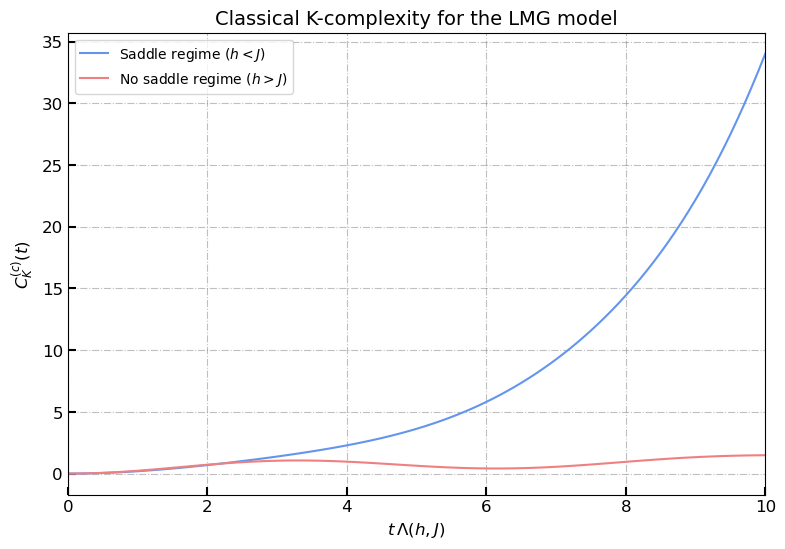

In [25]:
fig, ax = one_plot(
    title = 'Classical K-complexity for the LMG model',
    x_label = r'$t \,\Lambda(h,J)$',
    y_label = r'$C_K^{(c)}(t)$')

ax.plot(time_grid, classical_K_complexity_saddle, color = 'cornflowerblue', label = r'Saddle regime $(h<J)$')
ax.plot(time_grid, classical_K_complexity_nosaddle, color = 'lightcoral', label = r'No saddle regime $(h>J)$')
ax.set_xlim(0, 10)  

ax.legend(fontsize = 10)

plt.show()

In [20]:
a = 0.

ic_zz = [[[1, 0, 1, 0], 1.]]
FP_classical_zz_chaotic = classicalFP(a, ic_zz)
spectral_width_chaotic = FP_classical_zz_chaotic.spectral_width()
classical_Lanczos_FP_zz_chaotic = FP_classical_zz_chaotic.Lanczos_coeff_IT(50)
time_grid, classical_K_complexity_chaotic = K_complexity(10, 0.1, classical_Lanczos_FP_zz_chaotic / spectral_width_chaotic, True)

a = 0.9

FP_classical_zz_integrable = classicalFP(a, ic_zz)
spectral_width_integrable = FP_classical_zz_integrable.spectral_width()
classical_Lanczos_FP_zz_integrable = FP_classical_zz_integrable.Lanczos_coeff_IT(50)
time_grid, classical_K_complexity_integrable = K_complexity(10, 0.1, classical_Lanczos_FP_zz_integrable / spectral_width_integrable, True)

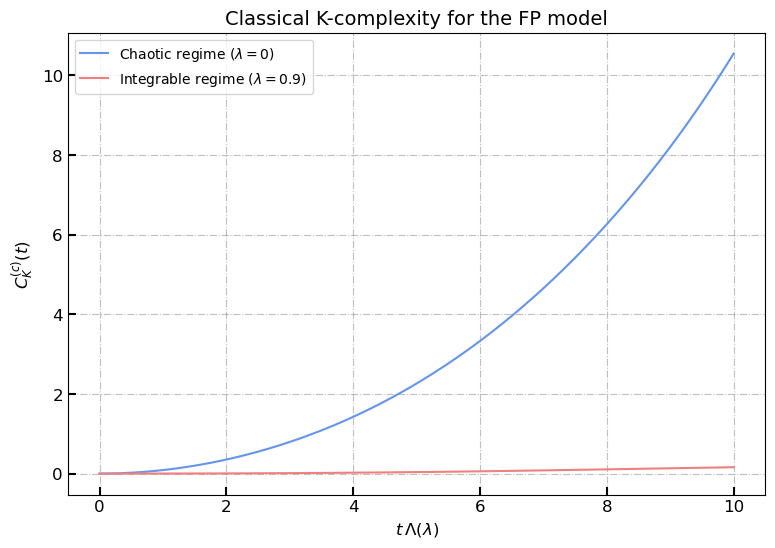

In [26]:
fig, ax = one_plot(
    title = 'Classical K-complexity for the FP model',
    x_label = r'$t\, \Lambda(\lambda)$',
    y_label = r'$C_K^{(c)}(t)$')

ax.plot(time_grid, classical_K_complexity_chaotic, color = 'cornflowerblue', label = r'Chaotic regime $(\lambda=0)$')
ax.plot(time_grid, classical_K_complexity_integrable, color = 'lightcoral', label = r'Integrable regime $(\lambda=0.9)$')

ax.legend(fontsize = 10)

plt.show()

In [ ]:
result = LMG_MC_classical.Lanczos_coeff_MC(30)

In [ ]:
result

In [ ]:
a = 0.
ic_zz = [[[1, 0, 1, 0], 1.], [[1, 0, 2, 1], -1.], [[2, 1, 1, 0], -1.], [[2, 1, 2, 1], 1.]]
b_number = 50
FP_classical = classicalFP(a, ic_zz)

In [ ]:
FP_classical.Lanczos_coeff_IT(b_number)

In [ ]:
a = 0.5
ic = [[[1, 0, 1, 0], 1]]
E = 0.
delta_E = 0.1
n_samples = 10 ** 5
FP_MC_classical = classicalFP_MC(a, ic, E, delta_E, n_samples)

In [ ]:
result = FP_MC_classical.Lanczos_coeff_MC(10)

In [ ]:
result

## <span style="color:orange">3.  Quantum Krylov complexity</span>

<span><i>In this section, $\textcolor{red}{bla bla}$. Why is it necessary to run on Mathematica?</i></span>

Some comments about the form of the initial operator and how it is encoded in a list for both models

The following piece of code prepares the parameters and the initial operator for executing the Lanczos algorithm on a Mathematica script. The script is ran behind the scene and the result are then stored in some variables of this notebook. The choice of <code>precision</code> is of uttermost importance -- if it is too small, the Lanczos algorithm may terminate earlier. On the other hand, if it is too large, numerical effort may be wasted.

Let's do some warm-up.

Add coefficient for intial operator in LMG!! 

In [ ]:
LMG_system = LMG(1, 1, 40)
H_LMG = LMG_system.build_intensive()

Sx, Sy, Sz = util.spin_operators(LMG_system.S)
identity_op = np.eye(2 * LMG_system.S + 1)
sx, sy, sz = Sx / LMG_system.S, Sy / LMG_system.S, Sz / LMG_system.S

time_grid = np.linspace(0, 1e3, num = int(1e4))
test_1 = LMG_system.autocorrelation(sz, time_grid) 
test_2 = LMG_system.autocorrelation(sy, time_grid) 
test_3 = LMG_system.autocorrelation(sz + sy, time_grid)
test_4 = LMG_system.autocorrelation(sz - sy, time_grid)

In [ ]:
import scipy.linalg as la

In [ ]:
np.trace(sz @ la.expm(-1j * H_LMG * 1.4524) @ sy @ la.expm(1j * H_LMG * 1.4524)) 

In [ ]:
np.trace(sy @ la.expm(1j * H_LMG * 1.4524) @ sz @ la.expm(-1j * H_LMG * 1.4524))

In [ ]:
print(test_1[3 * int(1e3)])
print(test_2[3 * int(1e3)])
print(test_3[3 * int(1e3)])
print(test_4[3 * int(1e3)])
print((test_1[3 * int(1e3)] + test_2[3 * int(1e3)]) / 2)

In [ ]:
FP_system = FP(0.5, 4)
H_FP = FP_system.build_intensive()

Lx, Ly, Lz = util.spin_operators(FP_system.L)
identity_op = np.eye(2 * FP_system.L + 1)
lx, ly, lz = Lx / FP_system.L, Ly / FP_system.L, Lz / FP_system.L

time_grid = np.linspace(0, 1e3, num = int(1e4))
test_1 = FP_system.autocorrelation(np.kron(ly, ly), time_grid)
test_2 = FP_system.autocorrelation(np.kron(lx, lz), time_grid)
test_3 = FP_system.autocorrelation(np.kron(ly, ly) + np.kron(lz, lx), time_grid)
test_4 = FP_system.autocorrelation(np.kron(ly, ly) - np.kron(lz, lx), time_grid)

In [ ]:
1 / 9 ** 4

In [ ]:
print(test_1[4 * int(1e3)])
print(test_2[4 * int(1e3)])
print(test_3[4 * int(1e3)])
print(test_4[4 * int(1e3)])
print((test_1[4 * int(1e3)] + test_2[4 * int(1e3)]) / 2)

In [ ]:
print(test_1[4 * int(1e3)])
print(test_2[4 * int(1e3)])
print(test_3[4 * int(1e3)])
print(test_4[4 * int(1e3)])
print((test_1[4 * int(1e3)] + test_2[4 * int(1e3)]) / 2)

In [ ]:
FP_system = FP(0.5, 4)
Lx, Ly, Lz = util.spin_operators(FP_system.L) 
lx, ly, lz = Lx / FP_system.L, Ly / FP_system.L, Lz / FP_system.L
identity_op = np.eye(2 * FP_system.L + 1)

time_grid = np.logspace(-4, 16, num = int(1e5)) * FP_system.spectral_width() / FP_system.L

In [ ]:
result_all = []

a_list = np.array([-0.95, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.95])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(lz, identity_op) + np.kron(identity_op, lz), time_grid)
    result_all.append(result)

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_z\otimes \hat{1}+\hat{1}\otimes\hat{m}_z$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, result.real, label = f"a = {a:.2f}")

ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')

plt.legend()
plt.savefig("../FP_autocorrelation_1.pdf", dpi = 300)
plt.show()

In [ ]:
result_all = []

a_list = np.array([-0.95, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.95])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(lx, lx), time_grid)
    result_all.append(result)

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_x\otimes \hat{m}_x$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, result.real, label = f"a = {a:.2f}")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_2.pdf", dpi = 300)
plt.show()

In [ ]:
result_all = []

a_list = np.array([-0.95, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.95])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(lx, lz), time_grid)
    result_all.append(result)

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_x\otimes \hat{m}_z$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, np.abs(result.real) ** 2, label = f"a = {a:.2f}")
ax.set_xlim(1e-3, 1.e16)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_3.pdf", dpi = 300)
plt.show()

In [ ]:
result_all = []

a_list = np.array([-0.95, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.95])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(ly, identity_op) + np.kron(identity_op, ly), time_grid)
    result_all.append(result)

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_y\otimes \hat{1}+\hat{1}\otimes\hat{m}_y$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, result.real, label = f"a = {a:.2f}")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_4.pdf", dpi = 300)
plt.show()

In [ ]:
FP_system = FP(0., 5)

Lx, Ly, Lz = util.spin_operators(FP_system.L) 
lx, ly, lz = Lx / FP_system.L, Ly / FP_system.L, Lz / FP_system.L
identity_op = np.eye(2 * FP_system.L + 1)

time_grid = np.logspace(-3, 17, num = int(1e5)) * FP_system.spectral_width() / (FP_system.L ** 2)
H_FP = FP_system.build_intensive()
result_1 = FP_system.autocorrelation(np.kron(lz, identity_op) + np.kron(identity_op, lz), time_grid)
result_2 = FP_system.autocorrelation(np.kron(lx, lx), time_grid)
result_3 = FP_system.autocorrelation(np.kron(lx, lz), time_grid)
result_4 = FP_system.autocorrelation(np.kron(ly, identity_op) + np.kron(identity_op, ly), time_grid)

result_1 = np.abs(result_1) ** 2
result_2 = np.abs(result_2) ** 2
result_3 = np.abs(result_3) ** 2
result_4 = np.abs(result_4) ** 2

In [ ]:
np.savetxt("../Project 2/Data/autocorrelation_FP_lambda_" + str(FP_system.a) + ".txt", [result_1, result_2, result_3, result_4])
np.savetxt("../Project 2/Data/autocorrelation_FP_lambda_" + str(FP_system.a) + "_time_grid.txt", time_grid)

In [ ]:
_, ax = one_plot(r"$L=4,\,\quad  \lambda=0$", "t", r"$|\varphi_0(t)|^2$")
ax.plot(time_grid, result_1, label = r"$\hat{l}_z\otimes \hat{1}+\hat{1}\otimes\hat{m}_z$")
ax.plot(time_grid, result_2, label = r"$\hat{l}_x\otimes \hat{m}_x$")
ax.plot(time_grid, result_3, label = r"$\hat{l}_x\otimes \hat{m}_z$")
ax.plot(time_grid, result_4, label = r"$\hat{l}_y\otimes \hat{1}+\hat{1}\otimes\hat{m}_y$")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_all_2.pdf", dpi = 300)
plt.show()

In [ ]:
result_all = []

a_list = np.array([-1, -0.99, -0.8, -0.6, -0.4, -0.2, 0., 0.2, 0.4, 0.6, 0.8, 0.99, 1])
for a in a_list:

    FP_system = FP(a, 4)
    H_FP = FP_system.build_intensive()
    result = FP_system.autocorrelation(np.kron(lz, identity_op) - np.kron(identity_op, lz), time_grid)
    result_all.append(result)

In [ ]:
D = 2 * FP_system.L + 1
A = np.kron(Lz, np.eye(D)) + np.kron(np.eye(D), Lz)
B = np.kron(Lz, np.eye(D)) - np.kron(np.eye(D), Lz)
np.allclose(A @ B - B @ A, np.zeros_like(A))

In [ ]:
np.trace(np.kron(lx @ lx, identity_op))

In [ ]:
FP_system = FP(-0.5, 4)
H_FP = FP_system.build_intensive()
test_1 = FP_system.autocorrelation(np.kron(lz, identity_op), time_grid) 
test_2 = FP_system.autocorrelation(np.kron(identity_op, lx), time_grid) 
test_3 = FP_system.autocorrelation(np.kron(lz, identity_op) + np.kron(identity_op, lx), time_grid)
test_4 = FP_system.autocorrelation(np.kron(lz, identity_op) - np.kron(identity_op, lx), time_grid)
test_5 = FP_system.autocorrelation(np.kron(lx, lx), time_grid)

In [ ]:
print(test_1[4 * int(1e4)])
print(test_2[4 * int(1e4)])
print(test_3[4 * int(1e4)])
print(test_4[4 * int(1e4)])

In [ ]:
_, ax = one_plot(r"$L=4\, \quad \mathcal{O}=\hat{l}_z\otimes \hat{1}-\hat{1}\otimes \hat{m}_z$", "t", r"$|\varphi_0(t)|^2$")
for a, result in zip(a_list, result_all):
    ax.plot(time_grid, result.real, label = f"a = {a:.2f}")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.savefig("../FP_autocorrelation_5.pdf", dpi = 300)
plt.show()

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, result_all[0].real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, test.real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, result.real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, result.real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

In [ ]:
_, ax = one_plot("Autocorrelation function of Sx for the LMG model", "t", "Autocorrelation")
plt.plot(time_grid, result.real, label = "Real part")
ax.set_xlim(1e-3, 1.e16)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.legend()
plt.show()

In [ ]:
h = 0.5
J = 1.0

LMG_Lanczos_1 = LanczosQuantum(model = 'LMG', spin_size = 20, param = [h, J], initial_operator = [[1, 0, 1]], precision = 1500)
LMG_Lanczos_1.Lanczos_coeff_IT()

In [ ]:
LMG_Lanczos_1.Lanczos

In [ ]:
def wrapper(h):
    
    J = 1.0

    LMG_Lanczos = KrylovQuantum(model = 'LMG', spin_size = 30, param = [h, J], initial_operator = [[1, 0, 1]], precision = 3000)
    LMG_Lanczos.Lanczos_coeff_IT()
    result = LMG_Lanczos.LT_K_complexity()[0] / LMG_Lanczos.K_dim

    return result

In [ ]:
h_list = np.array([0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000])
result_ratio_x_y = Parallel(n_jobs = - 1)(delayed(wrapper)(h) for h in h_list)

In [ ]:
fig, ax = one_plot(
    title = r'$\hat{s}_x+\hat{s}_y$',
    x_label = r'$h/J$',
    y_label = r'$\overline{C_K}/K$')

ax.plot(h_list, result_ratio_x_y, color = 'cornflowerblue')

ax.set_xscale('log')

plt.show()

In [ ]:
fig, ax = one_plot(
    title = r'$\hat{s}_y$',
    x_label = r'$h/J$',
    y_label = r'$\overline{C_K}/K$')

ax.plot(h_list, result_ratio_y, color = 'cornflowerblue')

ax.set_xscale('log')

plt.show()

In [ ]:
np.logspace(-3, 3, 31)

In [ ]:
np.log10(np.logspace(-3, 3, 10))

In [ ]:
fig, ax = one_plot(
    title = r'$\hat{s}_z$',
    x_label = r'$h/J$',
    y_label = r'$\overline{C_K}/K$')

ax.plot(h_list, result_ratio_z, color = 'cornflowerblue')

ax.set_xscale('log')

plt.show()

In [ ]:
fig, ax = one_plot(
    title = r'$\hat{s}_z$',
    x_label = r'$h/J$',
    y_label = r'$\overline{C_K}/K$')

ax.plot(h_list, result_ratio_x, color = 'cornflowerblue')

ax.set_xscale('log')

plt.show()

In [ ]:
fig, ax = one_plot(
    title = 'Lanczos sequences for the LMG model',
    x_label = r'$n$',
    y_label = r'$b_n$')

ax.scatter(np.arange(1, len(LMG_Lanczos_1.Lanczos) + 1), LMG_Lanczos_1.Lanczos, color = 'cornflowerblue', s = 5)

plt.show()

In [ ]:
LMG_Lanczos_1.LT_K_complexity()[0] / LMG_Lanczos_1.K_dim

In [ ]:
h = 0.5
J = 1

LMG_Lanczos_1 = LanczosQuantum(model = 'LMG', spin_size = 40, param = [h, J], initial_operator = [[1, 0, 1]], precision = 8000)
LMG_Lanczos_1.Lanczos_coeff_IT()

print("Done with h = 0.5")

In [ ]:
h = 2.0
J = 1.0

LMG_Lanczos_2 = LanczosQuantum(model = 'LMG', spin_size = 40, param = [h, J], initial_operator = [[1, 0, 1]], precision = 8000)
LMG_Lanczos_2.Lanczos_coeff_IT()  

print("Done with h = 2.0")

In [ ]:
LMG_Lanczos_2.Lanczos

In [ ]:
LMG_Lanczos_2.Lanczos

In [ ]:
len(np.loadtxt("../Project 2/Data/Lanczos_LMG_h2.0_J1_sz.txt"))
#np.savetxt("../Project 2/Data/Lanczos_LMG_h2.0_J1_sy.txt", LMG_Lanczos_2.Lanczos)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Lanczos sequences for the LMG model', r'$h<J$', r'$h>J$'],
    x_labels = [r'$n$', r'$n$'],
    y_labels = [r'$b_n$', r'$b_n$'])

ax1.scatter(np.arange(1, len(LMG_Lanczos_1.Lanczos) + 1), LMG_Lanczos_1.Lanczos, color = 'cornflowerblue', s = 5)
ax2.scatter(np.arange(1, len(LMG_Lanczos_2.Lanczos) + 1), LMG_Lanczos_2.Lanczos, color = 'lightcoral', s = 5)

plt.show()

In [ ]:
a = 0.0

FP_Lanczos_1 = KrylovQuantum(model = 'FP', spin_size = 4, param = [a], initial_operator = [[1, 3, 1, 0, 1], [- 1, 0, 1, 3, 1]], precision = 1000)
FP_Lanczos_1.Lanczos_coeff_IT()

a = 0.9

FP_Lanczos_2 = KrylovQuantum(model = 'FP', spin_size = 4, param = [a], initial_operator = [[1, 3, 1, 0, 1], [- 1, 0, 1, 3, 1]], precision = 1000)
FP_Lanczos_2.Lanczos_coeff_IT()

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Lanczos sequences for the FP model', r'$\lambda=0$', r'$\lambda=0.9$'],
    x_labels = [r'$n$', r'$n$'],
    y_labels = [r'$b_n$', r'$b_n$'])

ax1.scatter(np.arange(1, len(FP_Lanczos_1.Lanczos) + 1), FP_Lanczos_1.Lanczos, color = 'cornflowerblue', s = 5)
ax2.scatter(np.arange(1, len(FP_Lanczos_2.Lanczos) + 1), FP_Lanczos_2.Lanczos, color = 'lightcoral', s = 5)

plt.show()

In [ ]:
h = 1 / 2
J = 1

LMG_Lanczos_MC_1 = LanczosQuantum(model = 'LMG', spin_size = 75, param = [h, J], initial_operator = [[0, 0, 1]], precision = 1500)
LMG_Lanczos_MC_1.Lanczos_coeff_MC(E = -0.4, E_window = 0.2, one_point = False)

In [ ]:
len(LMG_Lanczos_MC_1.Lanczos)

In [ ]:
LMG_Lanczos_MC_1.K_dim

In [ ]:
h = 0.5
J = 1.0

LMG_Lanczos_MC_1 = LanczosQuantum(model = 'LMG', spin_size = 20, param = [h, J], initial_operator = [[0, 0, 1], [1, 0, 0]], precision = 750)
LMG_Lanczos_MC_1.Lanczos_coeff_MC(E = -0.1, E_window = 0.1, one_point = False)

h = 2.0
J = 1.0 

LMG_Lanczos_MC_2 = LanczosQuantum(model = 'LMG', spin_size = 20, param = [h, J], initial_operator = [[0, 0, 1]], precision = 750)
LMG_Lanczos_MC_2.Lanczos_coeff_MC(E = 0.5, E_window = 0.2, one_point = True)

In [ ]:
print(LMG_Lanczos_MC_1.K_dim)
print(LMG_Lanczos_MC_2.K_dim)

In [ ]:
LMG_Lanczos_MC_1.Lanczos

In [ ]:
LMG_Lanczos_MC_1.a_coeff

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Microcanonical Lanczos sequences for the LMG model', r'$h<J$ ($E=-0.5\pm 0.1$)', r'$h>J$ ($E=0.5\pm 0.1$)'],
    x_labels = [r'$n$', r'$n$'],
    y_labels = [r'$b_n$', r'$b_n$'])

ax1.scatter(np.arange(1, len(LMG_Lanczos_MC_1.Lanczos) + 1), LMG_Lanczos_MC_1.Lanczos, color = 'cornflowerblue', s = 5)
#ax2.scatter(np.arange(1, len(LMG_Lanczos_MC_2.Lanczos) + 1), LMG_Lanczos_MC_2.Lanczos, color = 'lightcoral', s = 5)

plt.show()

In [ ]:
a = 0.0

FP_Lanczos_MC_1 = LanczosQuantum(model = 'FP', spin_size = 3, param = [a], initial_operator = [[1, 3, 1, 0, 1], [1, 0, 1, 3, 1]], precision = 500)
a_MC_1 = FP_Lanczos_MC_1.Lanczos_coeff_MC(E = -1, E_window = 0.4, one_point = True)

a = 0.9 

FP_Lanczos_MC_2 = LanczosQuantum(model = 'FP', spin_size = 3, param = [a], initial_operator = [[1, 3, 1, 0, 1], [1, 0, 1, 3, 1]], precision = 500)
a_MC_2 = FP_Lanczos_MC_2.Lanczos_coeff_MC(E = 0, E_window = 0.4, one_point = True)    

In [ ]:
print(FP_Lanczos_MC_1.K_dim)
print(FP_Lanczos_MC_2.K_dim)

In [ ]:
fig, (ax1, ax2) = plot_side_by_side(
    title = ['Lanczos sequences for the FP model', r'$\lambda=0$ ($E=-1\pm 0.2$)', r'$\lambda=0.9$ ($E=\pm 0.2$)'],
    x_labels = [r'$n$', r'$n$'],
    y_labels = [r'$b_n$', r'$b_n$'])

ax1.scatter(np.arange(1, len(FP_Lanczos_MC_1.Lanczos) + 1), FP_Lanczos_MC_1.Lanczos, color = 'cornflowerblue', s = 5)
ax2.scatter(np.arange(1, len(FP_Lanczos_MC_2.Lanczos) + 1), FP_Lanczos_MC_2.Lanczos, color = 'lightcoral', s = 5)

plt.show()

Important: we need to terminate the Mathematica kernels manually.

In [ ]:
instances = [obj for obj in gc.get_objects() if isinstance(obj, KrylovQuantum)]

for i, obj in enumerate(instances):
    obj._session.terminate()
    print(f"[{i}] Session terminated.")

del instances
gc.collect()